# Theory of Black-Scholes Model

The **Black-Scholes model** is a mathematical model used to calculate the theoretical price of options, particularly **European options** (which can only be exercised at expiration). The model was developed by **Fischer Black**, **Myron Scholes**, and **Robert Merton** in 1973, and is one of the most widely used models in **financial mathematics**.

## Key Assumptions of the Black-Scholes Model

The Black-Scholes model is based on several assumptions about the market and the underlying asset. These assumptions include:

1. **The stock price follows a geometric Brownian motion (GBM)**: The stock price evolves continuously over time and is assumed to follow a random walk with constant volatility.
   
2. **No dividends are paid**: The model assumes the stock does not pay dividends during the life of the option.
   
3. **Markets are efficient**: Information is instantly available to all market participants, and there are no arbitrage opportunities.
   
4. **No transaction costs or taxes**: Buying and selling the option or underlying stock can be done without any friction or costs.
   
5. **Constant risk-free interest rate**: The rate at which money can be borrowed or lent is constant and known over the life of the option.

6. **European options**: The model is used to price **European options**, which can only be exercised at expiration, as opposed to **American options**, which can be exercised at any time before expiration.

# Black-Scholes Option Pricing Formulas

## Call Option Formula:
$C = S_0 N(d_1) - K e^{-rT} N(d_2)$

## Put Option Formula:
$P = K e^{-rT} N(-d_2) - S_0 N(-d_1)$

## Where:
- $(C)$ = Call option price
- $(P)$ = Put option price
- $(S_0)$ = Current stock price
- $(K)$ = Strike price
- $(r)$ = Risk-free interest rate
- $(T)$ = Time to expiration (in years)
- $N(x)$ = Cumulative distribution function (CDF) of the standard normal distribution
- $d_1 = \frac{\ln(S_0/K) + (r + \frac{\sigma^2}{2})T}{\sigma \sqrt{T}}$
- $d_2 = d_1 - \sigma \sqrt{T}$
- $(\sigma)$ = Volatility of the underlying asset

## Intuition Behind the Formula

The formula essentially represents the **expected present value of the option's payoff** at maturity, where:

- $(S_0)$ represents the current price of the underlying asset (stock).
- $(K)$ is the strike price of the option.
- $(r)$ is the risk-free rate, reflecting the time value of money.
- $(T)$ is the time remaining until the option expires.
- $(\sigma)$ represents the volatility of the underlying asset, capturing the uncertainty about future price movements.

### Key Components:
1. $S_0 N(d_1)$ represents the expected value of receiving the stock if the option expires in-the-money
2. $K e^{-rT} N(d_2)$ represents the present value of paying the strike price if the option expires in-the-money
3. The term $e^{-rT}$ is the discount factor that brings future values to present values
4. $N(d_1)$ and $N(d_2)$ represent probabilities under the risk-neutral measure

# Black-Scholes Options Greeks

The Greeks are important measures that describe the sensitivity of the option's price to various factors. The main Greeks in the Black-Scholes model include:

1. Delta (Δ):
   - Measures the sensitivity of the option's price to changes in the underlying asset's price.
   - For a call option, Δ ranges from 0 to 1, while for a put option, it ranges from -1 to 0.
   - Formula:
     * Call: $\Delta = N(d_1)$
     * Put: $\Delta = N(d_1) - 1$

2. Gamma (Γ):
   - Measures the rate of change of Delta with respect to changes in the underlying price.
   - It indicates how much Delta will change as the underlying price changes.
   - Formula: $\Gamma = \frac{N'(d_1)}{S_0 \sigma \sqrt{T}}$

3. Vega (ν):
   - Measures the sensitivity of the option's price to changes in volatility.
   - It indicates how much the price of the option will change for a 1% change in volatility.
   - Formula: $\nu = S_0 N'(d_1) \sqrt{T}$
   - It is the derivative of the option price with respect to volatility.

4. Theta (Θ):
   - Measures the sensitivity of the option's price to the passage of time, also known as time decay.
   - Formula:
     * Call: $\Theta = -\frac{S_0 N'(d_1) \sigma}{2\sqrt{T}} - rK e^{-rT} N(d_2)$
     * Put: $\Theta = -\frac{S_0 N'(d_1) \sigma}{2\sqrt{T}} + rK e^{-rT} N(-d_2)$

5. Rho (ρ):
   - Measures the sensitivity of the option's price to changes in the risk-free interest rate.
   - Formula:
     * Call: $\rho = KT e^{-rT} N(d_2)$
     * Put: $\rho = -KT e^{-rT} N(-d_2)$

Where:
- $N(x)$ is the cumulative distribution function of the standard normal distribution
- $N'(x)$ is the probability density function of the standard normal distribution
- $S_0$ is the current stock price
- $K$ is the strike price
- $r$ is the risk-free interest rate
- $T$ is the time to expiration
- $\sigma$ is the volatility of the underlying asset
## Limitations of the Black-Scholes Model

Although the Black-Scholes model is widely used, it has limitations:
1. **Assumption of constant volatility**: In reality, volatility is not constant and can vary over time.
2. **No dividends**: The model does not account for dividends paid by the underlying asset.
3. **European options only**: The model is designed for European-style options and cannot directly apply to American options, which can be exercised early.
4. **No transaction costs**: In real markets, transaction costs and taxes exist, which can affect option pricing.

## Conclusion

The **Black-Scholes model** is a fundamental tool in financial markets for option pricing. Despite its assumptions and limitations, it remains one of the most important models in the field of financial derivatives, helping traders and investors assess the value of options and make informed decisions.

In [100]:
import numpy as np
from scipy.stats import norm # to generate the normal distribution
import matplotlib.pyplot as plt

In [101]:
class BlackScholes:
    def __init__(self,S,K,T,r,sigma):
        """
        Initialize Black-Scholes Option Pricing Model
        
        Parameters:
        S0 (float): Current stock price
        K (float): Strike price
        T (float): Time to expiration (in years)
        r (float): Risk-free interest rate (decimal)
        sigma (float): Volatility of underlying asset (decimal)
        """
        self.S=float(S)
        self.K=float(K)
        self.T=float(T)
        self.r=float(r)
        self.sigma=float(sigma)
        self.d1=self._calculate_d1()
        self.d2=self._calculate_d2()
        
        #insert the functions 
    def _calculate_d1(self):
        """
        Calculate d1 for the Black-Scholes model
        """
        self.d1=(np.log(self.S/self.K)+(self.r+0.5*self.sigma**2)*self.T)/(self.sigma*np.sqrt(self.T))
        return self.d1
    def _calculate_d2(self):
        """
        Calculate d2 for the Black-Scholes model
        """
        self.d2=self.d1-self.sigma*np.sqrt(self.T)
        return self.d2
    def call_price(self):
        """
        Calculate the price of a call option using the Black-Scholes model
        """
        self.call_price=self.S*norm.cdf(self.d1)-self.K*np.exp(-self.r*self.T)*norm.cdf(self.d2)
        return self.call_price
    def put_price(self):
        """
        Calculate the price of a put option using the Black-Scholes model
        """
        self.put_price=self.K*np.exp(-self.r*self.T)*norm.cdf(-self.d2)-self.S*norm.cdf(-self.d1)
        return self.put_price
    def call_delta(self):
        """
        Calculate the delta of a call option using the Black-Scholes model
        """
        self.call_delta=norm.cdf(self.d1)
        return self.call_delta
    def put_delta(self):
        """
        Calculate the delta of a put option using the Black-Scholes model
        """
        self.put_delta=norm.cdf(-self.d1)
        return self.put_delta
    def call_gamma(self):
        """
        Calculate the gamma of a call option using the Black-Scholes model
        """
        self.call_gamma=norm.pdf(self.d1)/(self.S*self.sigma*np.sqrt(self.T))
        return self.call_gamma
    def put_gamma(self):
        """
        Calculate the gamma of a put option using the Black-Scholes model
        """
        return self.call_gamma()
    def call_vega(self):
        """
        Calculate the vega of a call option using the Black-Scholes model
        """
        self.call_vega=self.S*norm.pdf(self.d1)*np.sqrt(self.T)
        return self.call_vega
    def put_vega(self):
        """
        Calculate the vega of a put option using the Black-Scholes model
        """
        return self.call_vega()
    def call_theta(self):
        """
        Calculate the theta of a call option using the Black-Scholes model
        """
        self.call_theta=-self.S*norm.pdf(self.d1)*self.sigma/(2*np.sqrt(self.T))-self.r*self.K*np.exp(-self.r*self.T)*norm.cdf(self.d2)
        return self.call_theta
    def put_theta(self):
        """
        Calculate the theta of a put option using the Black-Scholes model
        """
        self.put_theta=-self.S*norm.pdf(self.d1)*self.sigma/(2*np.sqrt(self.T))+self.r*self.K*np.exp(-self.r*self.T)*norm.cdf(-self.d2)
        return self.put_theta
    def call_rho(self):
        """
        Calculate the rho of a call option using the Black-Scholes model
        """
        self.call_rho=self.K*self.T*np.exp(-self.r*self.T)*norm.cdf(self.d2)
        return self.call_rho
    def put_rho(self):
        """
        Calculate the rho of a put option using the Black-Scholes model
        """
        self.put_rho=-self.K*self.T*np.exp(-self.r*self.T)*norm.cdf(-self.d2)
        return self.put_rho


### Calculating Annualized (Realised)Volatility

In [102]:
"""Calculating the realised volatility of the stock""" 
import yfinance as yf
from datetime import datetime as dt , timedelta as td
end_date = dt.today().strftime('%Y-%m-%d')
start_date = (dt.today()-td(days=365)).strftime('%Y-%m-%d')
# Fetch historical data for Nifty 50 (symbol: ^NSEI)
nifty = yf.download("^NSEI",start_date,end_date)
nifty['daily_return'] = nifty['Adj Close'].pct_change()
nifty.dropna(inplace=True)
daily_volatility = nifty['daily_return'].std()
annual_volatility = daily_volatility*np.sqrt(252)
print(f"Annualized Historical Volatility (last 1 year): {annual_volatility * 100:.2f}%")

[*********************100%***********************]  1 of 1 completed

Annualized Historical Volatility (last 1 year): 14.30%


In [103]:
if __name__ == "__main__":
    #Testing on nifty
    # Example parameters
    S0 = 23707.90    # Current stock price
    K = 23700.00     # Strike price
    T = ((dt(2025,1,30)-dt(2025,1,7)).days+1)/365    #time in years
    r = 0.06857    # Risk-free rate (6.857%)
    sigma = annual_volatility # Volatility 
    
    # Create Black-Scholes model instance
    bs = BlackScholes(S0, K, T, r, sigma)
    
    # Calculate option prices
    call_price = bs.call_price()
    put_price = bs.put_price()
        # Print results
    print(f"Parameters:")
    print(f"Stock Price (S0): ${S0}")
    print(f"Strike Price (K): ${K}")
    print(f"Time to Expiration (T): {T} years")
    print(f"Risk-free Rate (r): {r*100}%")
    print(f"Volatility (σ): {sigma*100}%")
    print(f"\nOption Prices:")
    print(f"Call Option Price: ${call_price:.2f}")
    print(f"Put Option Price: ${put_price:.2f}")
    print(f"\nGreeks:")
    print(f"Call Delta: {bs.call_delta():.4f}")
    print(f"Put Delta: {-bs.put_delta():.4f}")
    print(f"Gamma: {bs.call_gamma():.4f}")



Parameters:
Stock Price (S0): $23707.9
Strike Price (K): $23700.0
Time to Expiration (T): 0.06575342465753424 years
Risk-free Rate (r): 6.857%
Volatility (σ): 14.304709612246386%

Option Prices:
Call Option Price: $406.34
Put Option Price: $291.82

Greeks:
Call Delta: 0.5598
Put Delta: -0.4402
Gamma: 0.0005


### Fetching Necessary Details from option chain

In [124]:
import requests
import pandas as pd

# Fetch Nifty Option Chain Data
url = "https://www.nseindia.com/api/option-chain-indices?symbol=NIFTY"

# Headers to simulate a browser request
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/85.0.4183.121 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9",
    "Accept-Encoding": "gzip, deflate, br"
}

# Fetch data from NSE API
session = requests.Session()
response = session.get("https://www.nseindia.com", headers=headers)  # First visit to set cookies

response = session.get(url, headers=headers)
data = response.json() # Parse JSON data

"""
data is a dictionary with keys: 'records' and 'filtered'

records contains complete, unfiltered data from the Nifty Option Chain API.
Structure:
data: A list of all option chain entries (calls and puts) across various expiry dates and strike prices.
expiryDates: A list of all available expiry dates.
timestamp: The timestamp of when the data was fetched.
underlyingValue: The current price of the NIFTY index.

filtered contains a pre-filtered subset of the option chain data. It focuses on the nearest expiry date and relevant strike prices close to the current NIFTY value
Structure:
CE: Filtered Call Option data.
PE: Filtered Put Option data.
data: Limited to strikes near the current NIFTY index (e.g., ±10 strikes around the spot price).
"""

# User-defined expiry date
TARGET_EXPIRY = '30-Jan-2025'  # desired expiry date

# Parse data
options_data = []
for record in data['records']['data']: # record contains expiryDate, strikePrice, CE, PE
    expiry_date = record['expiryDate']
    if expiry_date == TARGET_EXPIRY:  # Filter by specific expiry date
        strike_price = record['strikePrice']
        ltp_call = record.get('CE', {}).get('lastPrice', None)  # Call Option LTP
        ltp_put = record.get('PE', {}).get('lastPrice', None)   # Put Option LTP
        iv_call = record.get('CE', {}).get('impliedVolatility', None)
        iv_put = record.get('PE', {}).get('impliedVolatility', None)
        options_data.append({
            'expiry_date': expiry_date,
            'strike': strike_price,
            'ltp_call': ltp_call,
            'ltp_put': ltp_put,
            'iv_call': iv_call,
            'iv_put': iv_put,
        })

# Convert to DataFrame
df = pd.DataFrame(options_data)
if df.empty:
    print(f"No data found for expiry date: {TARGET_EXPIRY}")
else:
    print(f"Data fetched successfully for expiry date: {TARGET_EXPIRY}")

print(df)


Data fetched successfully for expiry date: 30-Jan-2025
    expiry_date  strike  ltp_call  ltp_put  iv_call  iv_put
0   30-Jan-2025   21600   2165.00     6.70     0.00   18.97
1   30-Jan-2025   21650      0.00     7.65     0.00   18.98
2   30-Jan-2025   21700   1964.40     7.95     0.00   18.79
3   30-Jan-2025   21750      0.00     9.40     0.00   18.78
4   30-Jan-2025   21800   1860.70    10.00     0.00   18.55
..          ...     ...       ...      ...      ...     ...
94  30-Jan-2025   26300      4.85     0.00    18.08    0.00
95  30-Jan-2025   26350      4.70     0.00    18.20    0.00
96  30-Jan-2025   26400      4.50  2650.00    18.45   32.52
97  30-Jan-2025   26450      4.50     0.00    18.68    0.00
98  30-Jan-2025   26500      4.25  2705.75    18.83   28.64

[99 rows x 6 columns]


### Actual option price vs BS option price

In [125]:
S=data['records']['underlyingValue']    # Current stock price
r = 0.06857    # Risk-free rate (6.857%)
sigma = annual_volatility # Volatility 
expiry_date = dt.strptime(TARGET_EXPIRY, "%d-%b-%Y")
today = dt.today()
T = (expiry_date - today).days / 365 + 1 / 365
df = df[(df['strike'] >= 23450) & (df['strike'] <= 24800)]
df['bs_call_price'] = df['strike'].apply(lambda K: BlackScholes(S, K, T, r, sigma).call_price())
df['bs_put_price'] = df['strike'].apply(lambda K: BlackScholes(S, K, T, r, sigma).put_price())
df

,expiry_date,strike,ltp_call,ltp_put,iv_call,iv_put,bs_call_price,bs_put_price
37,30-Jan-2025,23450,521.55,191.75,12.88,15.14,524.196273,188.527750
38,30-Jan-2025,23500,488.25,210.00,12.88,15.14,492.329066,206.454321
39,30-Jan-2025,23550,453.25,226.00,12.89,15.09,461.601943,225.520975
40,30-Jan-2025,23600,425.85,244.35,12.94,15.06,432.033171,245.745979
41,30-Jan-2025,23650,392.45,264.10,12.93,15.00,403.636982,267.143567
42,30-Jan-2025,23700,365.70,288.00,12.86,14.94,376.423450,289.723813
43,30-Jan-2025,23750,336.25,311.55,12.86,15.01,350.398406,313.492546
44,30-Jan-2025,23800,311.00,331.15,12.89,14.99,325.563401,338.451318
45,30-Jan-2025,23850,288.90,359.10,12.89,15.01,301.915717,364.597412
46,30-Jan-2025,23900,264.00,385.00,12.80,14.91,279.448426,391.923898


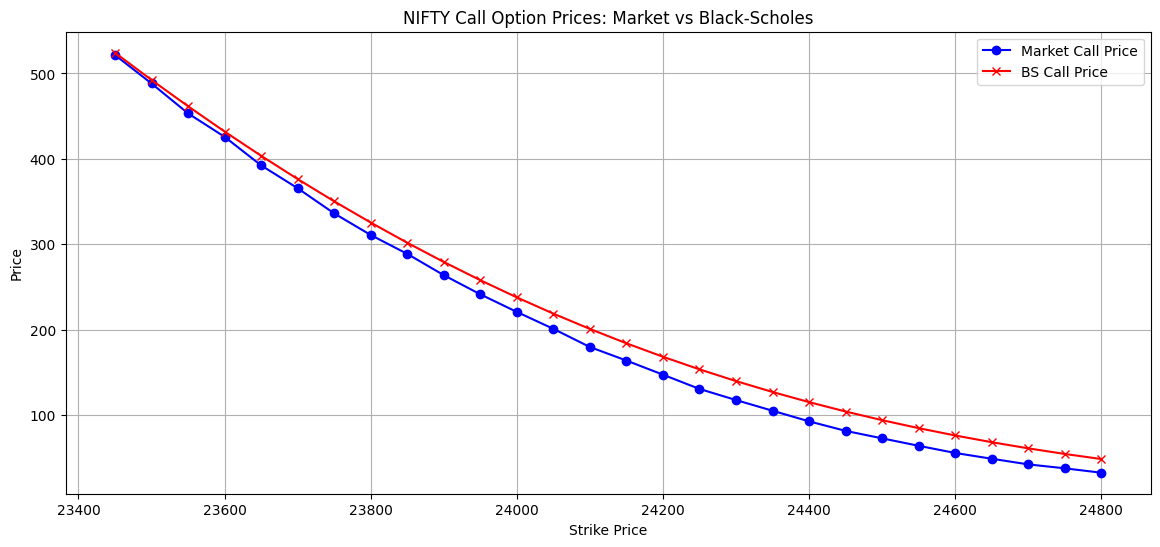

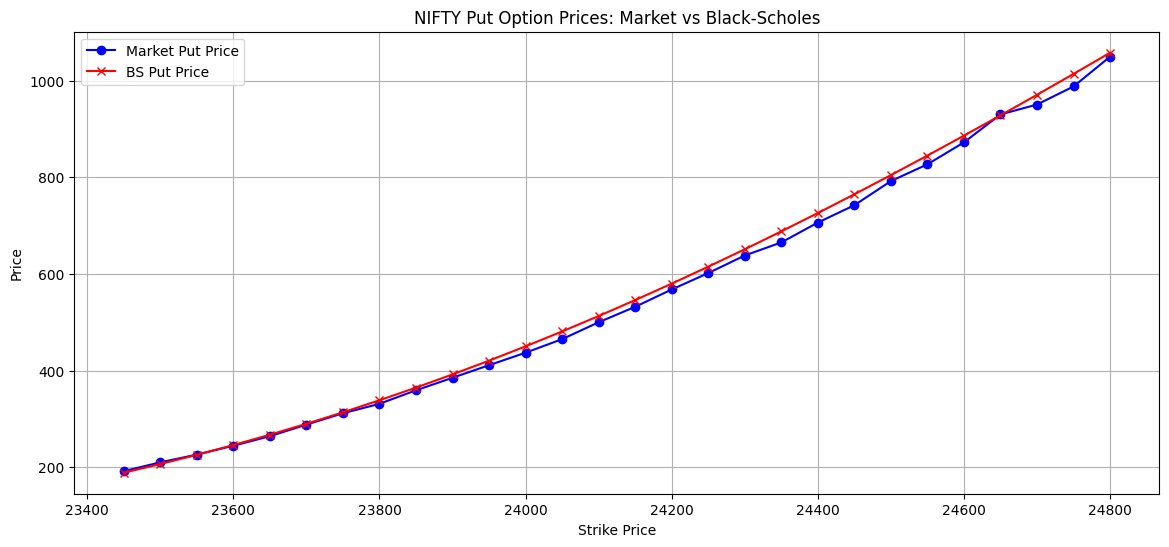

In [126]:
import matplotlib.pyplot as plt

# Plot Call Prices
plt.figure(figsize=(14, 6))
plt.plot(df['strike'], df['ltp_call'], 'o-', label='Market Call Price', color='b')
plt.plot(df['strike'], df['bs_call_price'], 'x-', label='BS Call Price', color='r')
plt.title('NIFTY Call Option Prices: Market vs Black-Scholes')
plt.xlabel('Strike Price')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# Plot Put Prices
plt.figure(figsize=(14, 6))
plt.plot(df['strike'], df['ltp_put'], 'o-', label='Market Put Price', color='b')
plt.plot(df['strike'], df['bs_put_price'], 'x-', label='BS Put Price', color='r')
plt.title('NIFTY Put Option Prices: Market vs Black-Scholes')
plt.xlabel('Strike Price')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


***If LTP > BS Price, the option might be overpriced.***

***If LTP < BS Price, the option might be underpriced.***

# 📚 **Implied Volatility and Its Calculation Using the Black-Scholes Model**

## **What is Implied Volatility?**

**Implied Volatility (IV)** is a measure of the market's expectation of the volatility of the underlying asset's price in the future. Unlike **realized volatility**, which is based on past price movements, implied volatility is derived from the **current market prices** of options.

IV is significant because it reflects how much market participants expect the price of an asset to move in the future. Higher IV means the market expects greater price fluctuations, while lower IV suggests the market expects price stability.

### **Calculating Implied Volatility**

**Implied Volatility** is the volatility that, when plugged into the Black-Scholes model, produces an option price equal to the current market price (LTP) of the option. Since the BS model calculates the theoretical price of an option, we can use an **iterative numerical method** to find the implied volatility that results in an option price equal to the market price.

# Steps to Calculate Implied Volatility (IV) Using the Black-Scholes Model:

1. Inputs:
   - Option type (Call or Put)
   - Current price of the underlying asset ($S$)
   - Strike price ($K$)
   - Time to expiration ($T$)
   - Risk-free interest rate ($r$)
   - Market Option Price (LTP)

2. Initial Guess for Volatility:
   - Start with an assumed volatility (e.g., 0.2 or 20%)

3. Calculate the Function Value and Derivative:
   - The function value:
     $f(\sigma_n) = BS_{price}(S, K, T, r, \sigma_n) - LTP$
   
   - The derivative ($f'(\sigma_n)$) is the partial derivative of the Black-Scholes price with respect to $\sigma$: (which is equivalent to vega)
     
     $f'(\sigma) = \frac{\partial}{\partial \sigma} \left[ S \cdot N(d_1) - K \cdot e^{-rT} \cdot N(d_2) \right]$
     
     This derivative can be simplified to:
     
     $f'(\sigma) = S \cdot \sqrt{T} \cdot \frac{1}{\sqrt{2\pi}} \cdot e^{-0.5 d_1^2}$

4. Update Volatility Guess:
   - Update the guess for volatility using the Newton-Raphson formula:
   $\sigma_{n+1} = \sigma_n - \frac{f(\sigma_n)}{f'(\sigma_n)}$

5. Repeat:
   - Repeat the process until the difference between the calculated price and the market price is below a small threshold (e.g., 0.001)

Where:
- $d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}$
- $d_2 = d_1 - \sigma\sqrt{T}$
- $N(x)$ is the cumulative distribution function of the standard normal distribution


In [129]:
# Define reasonable bounds for volatility
min_volatility = 0.01
max_volatility = 5.0
"""If the values of S (spot price) and K (strike price) are very large, the logarithm calculation in the Black-Scholes model might result in overflow.
If T (time to maturity) is very close to zero, the term involving np.sqrt(T) might lead to very large numbers.
If the volatility (σ) is extremely high, the value of d1 could become too large, especially when T is small."""
def implied_volatility(S, K, T, r, initial_guess, price, option_type):
	"""
	Calculate the implied volatility of an option using the Black-Scholes model
	
	Parameters:
	S (float): Current stock price
	K (float): Strike price
	T (float): Time to expiration (in years)
	r (float): Risk-free interest rate (decimal)
	price (float): Option price
	option_type (str): Option type ('call' or 'put')
	
	Returns:
	float: Implied volatility
	"""
	tolerance = 1e-5
	max_iter = 100
	i = 0
	bs = BlackScholes(S, K, T, r, initial_guess)
	if option_type == 'call':
		error = bs.call_price() - price #error is the function which needs to be minimized
	elif option_type == 'put':
		error = bs.put_price() - price
	else:
		raise ValueError("Invalid option type. Use 'call' or 'put'.")

	while abs(error) > tolerance and i < max_iter:
		bs = BlackScholes(S, K, T, r, initial_guess)
		if option_type == 'call':
			error = bs.call_price() - price
		elif option_type == 'put':
			error = bs.put_price() - price
		else:
			raise ValueError("Invalid option type. Use 'call' or 'put'.")
		vega = bs.call_vega() #vega same for call and put (it is the derivative of error function with respect to volatility)
		initial_guess -= error / vega
		# Ensure volatility remains within reasonable bounds
		if initial_guess < min_volatility:
			initial_guess = min_volatility
		elif initial_guess > max_volatility:
			initial_guess = max_volatility
		i += 1
	return initial_guess * 100

df['bs_iv_call'] = df.apply(lambda row: implied_volatility(S, row['strike'], T, r, annual_volatility, row['ltp_call'], 'call'), axis=1)
df['bs_iv_put'] = df.apply(lambda row: implied_volatility(S, row['strike'], T, r, annual_volatility, row['ltp_put'], 'put'), axis=1)
df

,expiry_date,strike,ltp_call,ltp_put,iv_call,iv_put,bs_call_price,bs_put_price,bs_iv_call,bs_iv_put
37,30-Jan-2025,23450,521.55,191.75,12.88,15.14,524.196273,188.527750,14.179841,14.456515
38,30-Jan-2025,23500,488.25,210.00,12.88,15.14,492.329066,206.454321,14.116760,14.467843
39,30-Jan-2025,23550,453.25,226.00,12.89,15.09,461.601943,225.520975,13.927444,14.326323
40,30-Jan-2025,23600,425.85,244.35,12.94,15.06,432.033171,245.745979,14.030136,14.242743
41,30-Jan-2025,23650,392.45,264.10,12.93,15.00,403.636982,267.143567,13.814254,14.171321
42,30-Jan-2025,23700,365.70,288.00,12.86,14.94,376.423450,289.723813,13.838993,14.229856
43,30-Jan-2025,23750,336.25,311.55,12.86,15.01,350.398406,313.492546,13.693716,14.220824
44,30-Jan-2025,23800,311.00,331.15,12.89,14.99,325.563401,338.451318,13.677024,13.990021
45,30-Jan-2025,23850,288.90,359.10,12.89,15.01,301.915717,364.597412,13.742734,14.067365
46,30-Jan-2025,23900,264.00,385.00,12.80,14.91,279.448426,391.923898,13.633986,14.004170


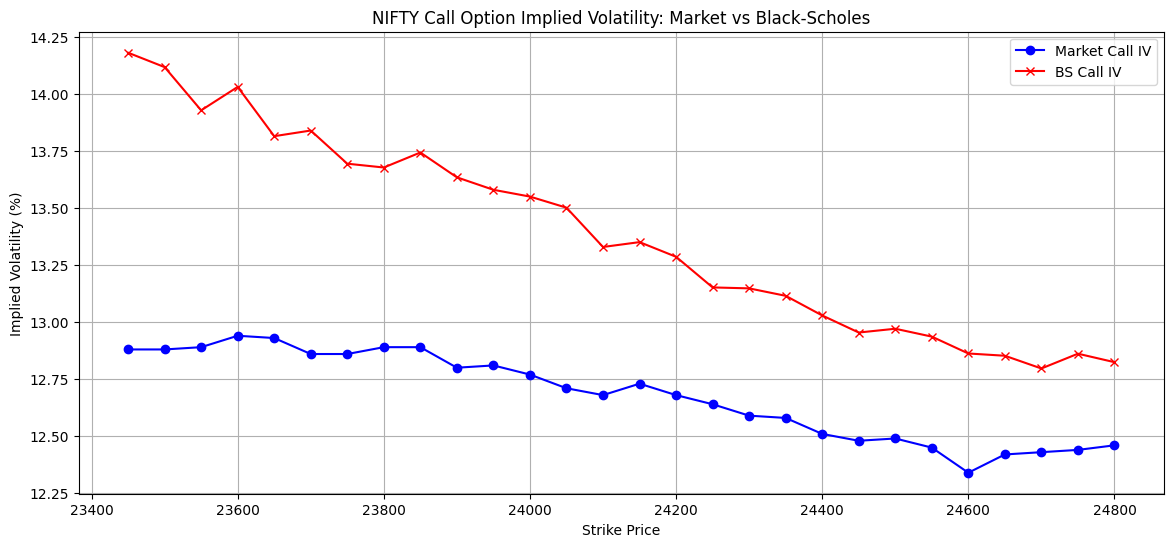

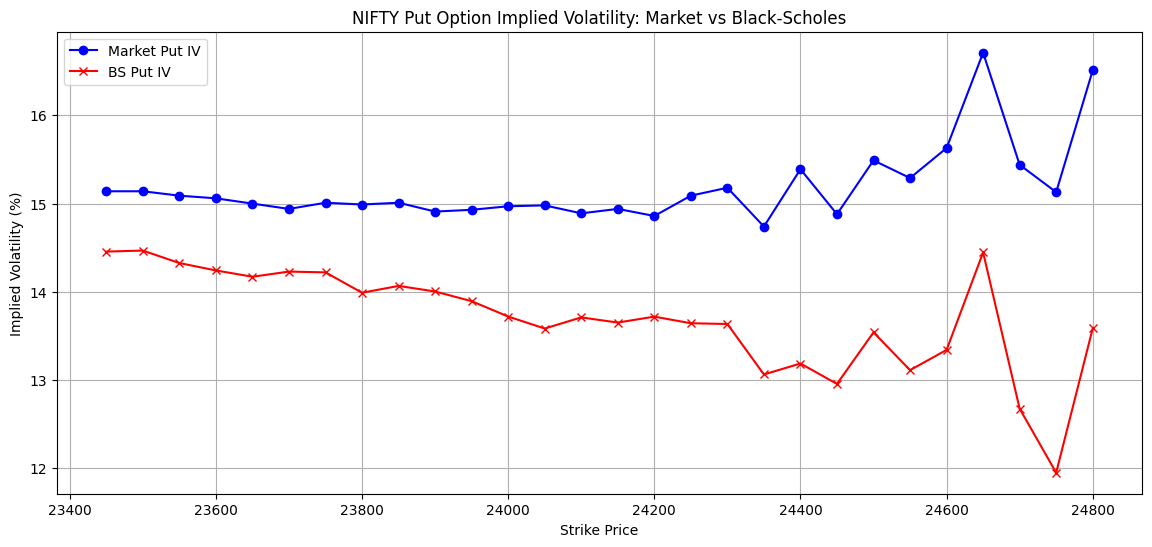

In [130]:
import matplotlib.pyplot as plt

# Plot Call Prices
plt.figure(figsize=(14, 6))
plt.plot(df['strike'], df['iv_call'], 'o-', label='Market Call IV', color='b')
plt.plot(df['strike'], df['bs_iv_call'], 'x-', label='BS Call IV', color='r')
plt.title('NIFTY Call Option Implied Volatility: Market vs Black-Scholes')
plt.xlabel('Strike Price')
plt.ylabel('Implied Volatility (%)')
plt.legend()
plt.grid(True)
plt.show()

# Plot Put Prices
plt.figure(figsize=(14, 6))
plt.plot(df['strike'], df['iv_put'], 'o-', label='Market Put IV', color='b')
plt.plot(df['strike'], df['bs_iv_put'], 'x-', label='BS Put IV', color='r')
plt.title('NIFTY Put Option Implied Volatility: Market vs Black-Scholes')
plt.xlabel('Strike Price')
plt.ylabel('Implied Volatility (%)')
plt.legend()
plt.grid(True)
plt.show()

